In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [2]:
house_data = pd.read_csv("HousePricePrediction.csv")
house_data
clean_house_data = house_data.dropna()
clean_house_data

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1455,60,RL,7917,Inside,1Fam,5,1999,2000,VinylSd,0.0,953.0,175000.0
1456,1456,20,RL,13175,Inside,1Fam,6,1978,1988,Plywood,163.0,1542.0,210000.0
1457,1457,70,RL,9042,Inside,1Fam,9,1941,2006,CemntBd,0.0,1152.0,266500.0
1458,1458,20,RL,9717,Inside,1Fam,6,1950,1996,MetalSd,1029.0,1078.0,142125.0


In [3]:
clean_house_data["MSZoning"].unique()

array(['RL', 'RM', 'C (all)', 'FV', 'RH'], dtype=object)

In [4]:
clean_house_data["LotConfig"].unique()

array(['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3'], dtype=object)

In [5]:
clean_house_data["Exterior1st"].unique()

array(['VinylSd', 'MetalSd', 'Wd Sdng', 'HdBoard', 'BrkFace', 'WdShing',
       'CemntBd', 'Plywood', 'AsbShng', 'Stucco', 'BrkComm', 'AsphShn',
       'Stone', 'ImStucc', 'CBlock'], dtype=object)

In [6]:
clean_house_data["BldgType"].unique()

array(['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs'], dtype=object)

<Axes: xlabel='OverallCond', ylabel='SalePrice'>

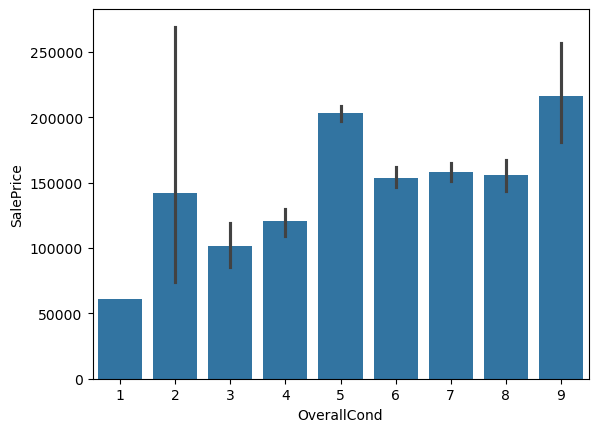

In [7]:
# 1. visualise data to see any patters

# sns.barplot(x = house_data["OverallCond"], y = house_data["SalePrice"])
sns.barplot(x = clean_house_data["OverallCond"], y = clean_house_data["SalePrice"])

In [8]:
# 2. pre processing and feature engineering

X = clean_house_data.drop(columns = ["Id","SalePrice"])
y = clean_house_data["SalePrice"]

# one hot encoding
X = pd.get_dummies(X, columns = ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st'], drop_first=True, dtype = int)

# nothing to encode as we have dropped the features

In [9]:
# 3. Train test split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
254,20,8400,6,1957,1957,0.0,1314.0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
1066,60,7837,7,1993,1994,0.0,799.0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
638,30,8777,7,1910,1950,0.0,796.0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
799,50,7200,7,1937,1950,0.0,731.0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
380,50,5000,6,1924,1950,0.0,1026.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,20,9317,5,2006,2006,0.0,1314.0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1130,50,7804,3,1928,1950,0.0,1122.0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1294,20,8172,7,1955,1990,0.0,864.0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
860,50,7642,8,1918,1998,0.0,912.0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [10]:
# 4. create and train the model 

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
# 5. predict values

y_predictions = model.predict(X_test)

In [12]:
# 6. evaluate using metrics

# a). R^2 
r2 = r2_score(y_test, y_predictions)
print(f"R^2 = {r2}\n")

# b). MAE
print(f"MAE: {mean_absolute_error(y_test, y_predictions)} \n")

# c). RMSE
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_predictions))} \n")

# d). adjustedR^2
print(X_test.shape) # tells us how many rows and columns in the test data so that we can put in adj r^2 formula

n = X_test.shape[0] # rows of our inputs
p = X_test.shape[1] # cols of our inputs

adj_r2 = 1 - ( (1-r2) * (n-1) / (n-p-1) )
print(f"Adjusted R squared : {adj_r2}")

R^2 = 0.6195131796544822

MAE: 34122.854432150365 

RMSE: 54022.75473895723 

(292, 33)
Adjusted R squared : 0.5708462607730787
